   Free  Offer  Money  Urgent  Spam
0     1      1      1       1     1
1     1      1      0       1     1
2     0      0      0       0     0
3     0      0      0       0     0
4     1      1      1       0     1
5     0      0      0       0     0
6     1      0      1       1     1
7     0      0      0       0     0
Dataset Inspection

Shape
(8, 5)

Columns
Index(['Free', 'Offer', 'Money', 'Urgent', 'Spam'], dtype='str')

Info
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Free    8 non-null      int64
 1   Offer   8 non-null      int64
 2   Money   8 non-null      int64
 3   Urgent  8 non-null      int64
 4   Spam    8 non-null      int64
dtypes: int64(5)
memory usage: 452.0 bytes
None

Describe
           Free     Offer     Money    Urgent      Spam
count  8.000000  8.000000  8.000000  8.000000  8.000000
mean   0.500000  0.375000  0.375000  0.375000  0.500000
std

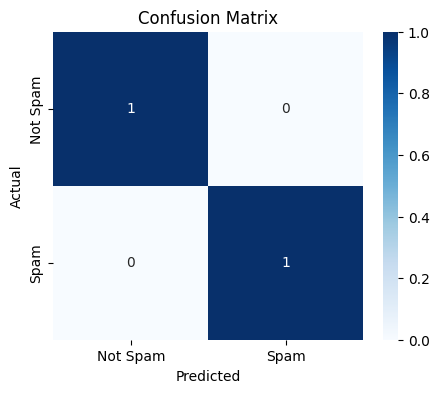

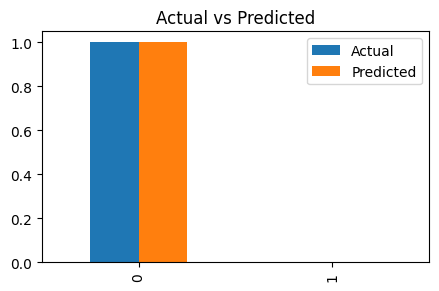

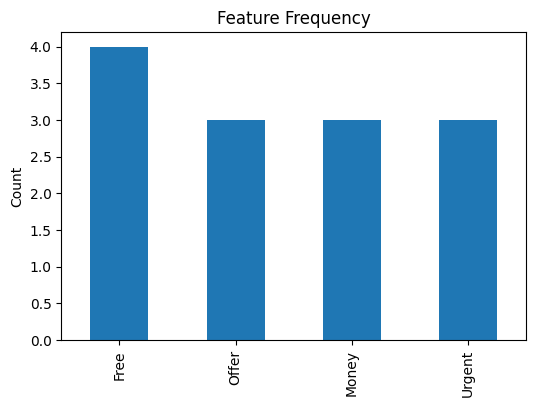

In [2]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================
# Dataset
# ==========================
data = {
    "Free":[1,1,0,0,1,0,1,0],
    "Offer":[1,1,0,0,1,0,0,0],
    "Money":[1,0,0,0,1,0,1,0],
    "Urgent":[1,1,0,0,0,0,1,0],
    "Spam":[1,1,0,0,1,0,1,0]
}

df = pd.DataFrame(data)

print(df)

print("==========================")
print("Dataset Inspection")
print("==========================")
print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInfo")
print(df.info())

print("\nDescribe")
print(df.describe())

# ==========================
# Feature Selection
# ==========================
X = df[["Free","Offer","Money","Urgent"]]
y = df["Spam"]

# ==========================
# Train Test Split
# ==========================
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# Gaussian Naive Bayes
# ==========================
model = GaussianNB()

model.fit(X_train,y_train)

# ==========================
# Prediction
# ==========================
new = pd.DataFrame([[1,1,0,1]],
columns=["Free","Offer","Money","Urgent"])

prediction = model.predict(new)

if prediction[0]==1:
    print("\nSpam Email")
else:
    print("\nNot Spam")

# ==========================
# Probability
# ==========================
print("\nProbability")
print(model.predict_proba(new))

# ==========================
# Accuracy
# ==========================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("\nAccuracy :",accuracy*100)

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix")
print(cm)

# ==========================
# Classification Report
# ==========================
print("\nClassification Report")
print(classification_report(y_test,y_pred))

# ==========================
# Experiment
# Gaussian NB vs KNN
# ==========================

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test,knn_pred)

print("\nGaussian NB Accuracy :",accuracy*100)
print("KNN Accuracy :",knn_accuracy*100)

if accuracy > knn_accuracy:
    print("Gaussian Naive Bayes performs better.")
elif accuracy < knn_accuracy:
    print("KNN performs better.")
else:
    print("Both models perform equally.")

# ==========================
# Visualization 1
# Confusion Matrix Heatmap
# ==========================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Spam","Spam"],
    yticklabels=["Not Spam","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================
# Visualization 2
# Actual vs Predicted
# ==========================

comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred
})

comparison.plot(kind="bar",figsize=(5,3))

plt.title("Actual vs Predicted")
plt.show()

# ==========================
# Visualization 3
# Feature Frequency
# ==========================

df[["Free","Offer","Money","Urgent"]].sum().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Feature Frequency")
plt.ylabel("Count")
plt.show()